In [1]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk

In [2]:
DATA_DIR = "mu3e_trigger_data"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_positions.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_positions.npy"

max_barrel_radius = 86.3
max_endcap_distance = 372.6

In [58]:
signal_data = np.load(SIGNAL_DATA_FILE)
background_data = np.load(BACKGROUND_DATA_FILE)

In [59]:
background_data = background_data[~(background_data[:, :, 0] == -1).all(axis=1)]
signal_data = signal_data[~(signal_data[:, :, 0] == -1).all(axis=1)]

In [5]:
def RotMatrix3D(angle):
    return np.array(
        [
            [np.cos(angle), -np.sin(angle), 0],
            [np.sin(angle), np.cos(angle), 0],
            [0, 0, 1],
        ]
    )

def generate_contrastive_data(data, num_angles = 4):
    angles = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)
    mask = (data == -1).all(axis = -1)
    rotation_matrices = np.stack([RotMatrix3D(angle) for angle in angles])
    rotated_data = np.einsum("ijk,lkm->ijlm", data, rotation_matrices)
    rotated_data[mask, :] = -1
    return [rotated_data[:, :, i, :] for i in range(num_angles)]

In [6]:
from src.model.components import (
    GenerateMask,
    PointTransformerBlock,
    SelfAttentionStack,
    PoolingAttentionBlock,
    MLP,
)

input_layer = keras.layers.Input(shape=(256, 3))

mask = GenerateMask(padding_value=-1)(input_layer)

input_embedding = MLP(
    output_dim=16,
    activation="linear",
    name="input_embedding"
)(input_layer)

transformer = SelfAttentionStack(stack_size=3, num_heads=8, key_dim=16)(
    input_embedding, mask
)

pooling = keras.layers.GlobalAveragePooling1D()(transformer, mask = mask)

latent_output = MLP(
    output_dim=16,
    activation="linear",
    name="final_latent_output"
)(pooling)

embedding_model = keras.Model(inputs=input_layer, outputs=latent_output, name="embedding_model")

In [7]:
def build_siamese_network(input_shape, base_model, num_contrastive_views=4):
    # Create multiple input layers
    views = [keras.layers.Input(shape=input_shape, name=f"input_view_{i}") for i in range(num_contrastive_views)]
    
    # Apply shared model to each input
    model_outputs = [base_model(view) for view in views]
        
    # Concatenate embeddings
    concatenated_views = keras.layers.Concatenate(axis=-1, name="concatenated_embeddings")(model_outputs)
    
    # Build Model
    return keras.Model(inputs=views, outputs=concatenated_views, name="siamese_network")


In [8]:
class CovarianceLoss(keras.losses.Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, _, y_pred):
        z = y_pred  # shape: (batch_size, latent_dim)
        batch_size = tf.cast(tf.shape(z)[0], tf.float32)
        z_size = tf.cast(tf.shape(z)[1], tf.float32)

        # Compute covariance matrix
        z_centered = z - tf.reduce_mean(z, axis=0)
        cov_matrix = tf.matmul(z_centered, z_centered, transpose_a=True) / (
            batch_size - 1.0
        )

        off_diag_mask = 1.0 - tf.eye(z_size)
        loss = tf.reduce_sum(tf.square(cov_matrix * off_diag_mask)) / z_size
        return loss

class VarianceLoss(keras.losses.Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, _, y_pred):
        z = y_pred  # shape: (batch_size, latent_dim)
        return tf.reduce_mean(tf.maximum(0., 1- tf.sqrt(tf.math.reduce_variance(z, axis=0) + 1e-4)))

class SWDLoss(tf.keras.losses.Loss):
    def __init__(self, reg_weight=1.0, num_projections=50, name="swd_loss"):
        super().__init__(name=name)
        self.reg_weight = reg_weight
        self.num_projections = num_projections

    def call(self, y_true, y_pred):
        z = y_pred

        prior_z = tf.random.normal(tf.shape(z))
        batch_size = tf.shape(z)[0]
        latent_dim = tf.shape(z)[1]

        # Random directions
        projections = tf.random.normal([self.num_projections, latent_dim])
        projections = tf.math.l2_normalize(projections, axis=-1)  # [P, D]

        proj_z = tf.linalg.matmul(z, projections, transpose_b=True)  # [B, P]
        proj_prior = tf.linalg.matmul(prior_z, projections, transpose_b=True)  # [B, P]

        proj_z_sorted = tf.sort(proj_z, axis=0)
        proj_prior_sorted = tf.sort(proj_prior, axis=0)

        swd = tf.reduce_mean(tf.square(proj_z_sorted - proj_prior_sorted))

        return self.reg_weight * swd
    
class ContrastiveLoss(keras.losses.Loss):
    def __init__(self, contrastive_views = 4, var_mtpl = 1, cov_mtpl = 1, **kwargs):
        super().__init__(**kwargs)
        self.contrastive_views = contrastive_views
        self.var_mtpl = var_mtpl
        self.cov_mtpl = cov_mtpl
        self.cov_loss = CovarianceLoss()
        self.var_loss = VarianceLoss()
        self.swd_loss = SWDLoss()
    
    def call(self, y_true, y_pred):
        outputs = tf.split(y_pred, self.contrastive_views, axis=-1)
        loss = 0.0
        for i in range(self.contrastive_views):
            # Compute pairwise contrastive loss
            for j in range(i + 1, self.contrastive_views):
                loss += tf.reduce_mean(
                    tf.square(outputs[i] - outputs[j]) 
                ) / (self.contrastive_views - 1)
            loss += self.var_mtpl * self.var_loss(outputs[i], outputs[i])
            loss += self.cov_mtpl * self.cov_loss(outputs[i], outputs[i])
            loss += self.swd_loss(outputs[i], outputs[i])
        return loss

In [9]:
from sklearn.model_selection import train_test_split
train_bg_data, test_bg_data = train_test_split(
    background_data, test_size=0.2, random_state=42, shuffle=True
)

In [10]:
contrast_views = 3
contrasted_train_bg_data = generate_contrastive_data(train_bg_data[:10000], contrast_views)
siamese_model = build_siamese_network(
    input_shape=(256, 3),
    base_model=embedding_model,
    num_contrastive_views=contrast_views,
)
siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=ContrastiveLoss(contrastive_views=contrast_views, var_mtpl=1, cov_mtpl=1),
)
siamese_model.summary()

Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_view_0        │ (None, 256, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_view_1        │ (None, 256, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_view_2        │ (None, 256, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 16)        │     27,834 │ input_view_0[0][… │
│ (Functional)        │                   │            │ input_view_1[0][… │
│                     │                   │            │ input_view_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenated_embed… │ (None, 48)        │          0 │ embedding_model[… │
│ (Concatenate)       │                   │            │ embedding_model[… │
│                     │                   │            │ embedding_model[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,834 (108.73 KB)

 Trainable params: 27,834 (108.73 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
siamese_model.fit(
    contrasted_train_bg_data,
    np.zeros((contrasted_train_bg_data[0].shape[0], 16 * contrast_views)),  # Dummy labels
    batch_size=512,
    epochs=10,
    validation_split=0.2,
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 476s 30s/step - loss: 4.6435 - val_loss: 3.9490
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 550s 35s/step - loss: 3.7648 - val_loss: 3.4530
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 644s 40s/step - loss: 3.4348 - val_loss: 3.2233
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 676s 42s/step - loss: 3.1970 - val_loss: 3.0589
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 587s 36s/step - loss: 3.0115 - val_loss: 2.8876
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 597s 37s/step - loss: 2.8463 - val_loss: 2.6734
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 576s 36s/step - loss: 2.6562 - val_loss: 2.5328
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 639s 40s/step - loss: 2.4750 - val_loss: 2.3915
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 691s 43s/step - loss: 2.3401 - val_loss: 2.3973
Epoch 10/10
 1/16 ━━━━━━━━━━━━━━━━━━━━ 10:07 40s/step - loss: 2.3221

KeyboardInterrupt: 

In [15]:
embedded_bg_train_data = embedding_model.predict(train_bg_data)


2491/2491 ━━━━━━━━━━━━━━━━━━━━ 373s 150ms/step


In [55]:
import src.model.VarAutoEncoder as var_ae
from importlib import reload
reload(var_ae)

var_ae = var_ae.VarAutoEncoder(
    input_size=16,
    latent_dim=8,
    nodes=4,
    name="autoencoder"
)
var_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss = var_ae.get_loss_object()
)
var_ae.fit(
    embedded_bg_train_data,
    embedded_bg_train_data,
    batch_size=512,
    epochs=1000,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=50,
            restore_best_weights=True,
        ),
    ],
)

Epoch 1/1000


/Users/simi/miniforge3/envs/mu3e_trigger/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'autoencoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.1144 - val_loss: 6.7018
Epoch 2/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 6.3575 - val_loss: 5.2660
Epoch 3/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 4.9330 - val_loss: 3.9671
Epoch 4/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 3.7523 - val_loss: 3.1405
Epoch 5/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 2.9756 - val_loss: 2.6467
Epoch 6/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step - loss: 2.5819 - val_loss: 2.3677
Epoch 7/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 2.3068 - val_loss: 2.1340
Epoch 8/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - loss: 2.0828 - val_loss: 1.9245
Epoch 9/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - loss: 1.8686 - val_loss: 1.6826
Epoch 10/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - loss: 1.6313 - val_loss: 1.4786
Epoch 11/1000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - loss: 1.4467 - val_loss: 1.3597
Epoch 12/1000
125/125 ━

In [16]:
from src.model import AutoEncoder

autoencoder = AutoEncoder(
    input_size=16,
    latent_dim=4,
    num_layers=4,
    name="autoencoder"
)
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.MeanSquaredError(),
)

In [19]:
autoencoder.fit(
    embedded_bg_train_data,
    embedded_bg_train_data,
    epochs=1000,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=50, restore_best_weights=True
        )
    ],
)

Epoch 1/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - loss: 0.0030 - val_loss: 0.0030
Epoch 2/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 431us/step - loss: 0.0029 - val_loss: 0.0028
Epoch 3/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - loss: 0.0028 - val_loss: 0.0027
Epoch 4/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 409us/step - loss: 0.0027 - val_loss: 0.0026
Epoch 5/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - loss: 0.0026 - val_loss: 0.0025
Epoch 6/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - loss: 0.0026 - val_loss: 0.0025
Epoch 7/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 407us/step - loss: 0.0025 - val_loss: 0.0025
Epoch 8/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 410us/step - loss: 0.0025 - val_loss: 0.0024
Epoch 9/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 410us/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 430us/step - loss: 0.0024 - val_loss: 0.0024
Epoch 11/1000
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 1s 428us/step - loss: 0.0023 - val

In [60]:
embedded_bg_test_data = embedding_model.predict(test_bg_data[:10000])
embedded_signal_data = embedding_model.predict(signal_data[:10000])


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step


In [76]:
varae_bg_test_data = var_ae.predict(embedded_bg_test_data)
varae_signal_data = var_ae.predict(embedded_signal_data)
varae_bg_train_data = var_ae.predict(embedded_bg_train_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 201us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 195us/step
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 0s 182us/step


In [80]:
test_x, test_mu, test_logvar = np.split(varae_bg_test_data, 3, axis=-1)
signal_x, signal_mu, signal_logvar = np.split(varae_signal_data, 3, axis=-1)
train_x, train_mu, train_logvar = np.split(varae_bg_train_data, 3, axis=-1)


In [81]:
test_var = np.exp(test_logvar)
signal_var = np.exp(signal_logvar)
train_var = np.exp(train_logvar)

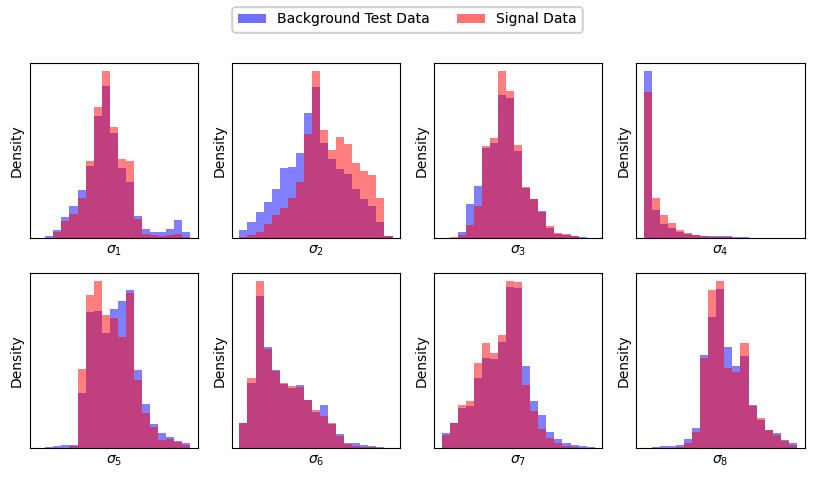

In [120]:
fig, ax_array = plt.subplots(figsize=(10, 5), nrows=2, ncols=4)
for i in range(8):
    ax = ax_array[i // 4, i % 4]
    bg_ad_score = test_var[:, i]
    signal_ad_score = signal_var[:, i]
    bins = np.linspace(min(np.min(bg_ad_score), np.min(signal_ad_score)), max(np.max(bg_ad_score), np.max(signal_ad_score)), 20)
    ax.hist(
        bg_ad_score,
        bins=bins,
        alpha=0.5,
        label="Background Test Data",
        color="blue",
        density=True,
    )
    ax.hist(
        signal_ad_score,
        bins=bins,
        alpha=0.5,
        label="Signal Data",
        color="red",
        density=True,
    )
    ax.set_xlabel(f"$\sigma_{i+1}$")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("Density")
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
fig.savefig("ad_scores_sig_bg.png", dpi=300, bbox_inches='tight')

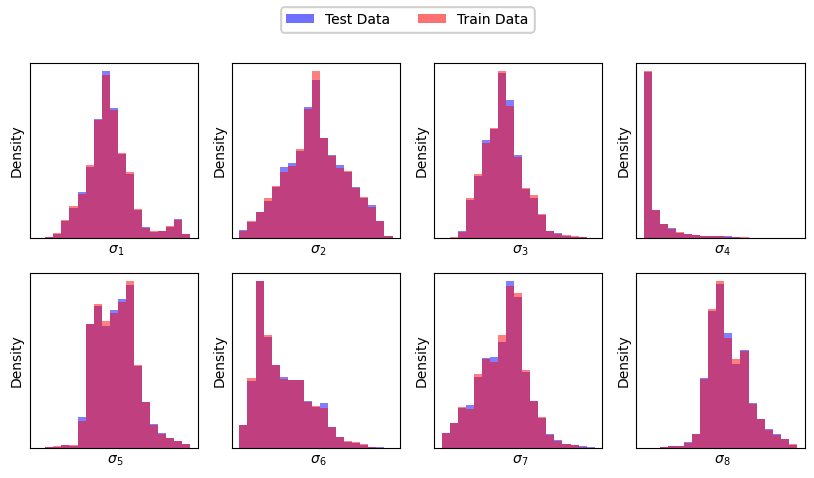

In [ ]:
fig, ax_array = plt.subplots(figsize=(10, 5), nrows=2, ncols=4)
for i in range(8):
    ax = ax_array[i // 4, i % 4]
    bg_ad_score = test_var[:, i]
    signal_ad_score = train_var[:, i]
    bins = np.linspace(min(np.min(bg_ad_score), np.min(signal_ad_score)), max(np.max(bg_ad_score), np.max(signal_ad_score)), 20)
    ax.hist(
        bg_ad_score,
        bins=bins,
        alpha=0.5,
        label="Test Data",
        color="blue",
        density=True,
    )
    ax.hist(
        signal_ad_score,
        bins=bins,
        alpha=0.5,
        label="Train Data",
        color="red",
        density=True,
    )
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel(f" $\sigma_{i+1}$")
    ax.set_ylabel("Density")
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
fig.savefig("ad_scores_train_test.png", dpi=300, bbox_inches='tight')

In [21]:
diff_bg_test = np.linalg.norm(
    embedded_bg_test_data - autoencoder.predict(embedded_bg_test_data), axis=1
)
diff_signal = np.linalg.norm(
    embedded_signal_data - autoencoder.predict(embedded_signal_data), axis=1
)
diff_bg_train = np.linalg.norm(
    embedded_bg_train_data - autoencoder.predict(embedded_bg_train_data), axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 221us/step
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step


In [23]:
autoencoder.evaluate(
    embedded_bg_train_data,
    embedded_bg_train_data,
    batch_size=32,
)

2491/2491 ━━━━━━━━━━━━━━━━━━━━ 1s 240us/step - loss: 0.0012


0.001238428638316691

In [24]:
autoencoder.evaluate(
    embedded_bg_test_data,
    embedded_bg_test_data,
    batch_size=32,
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 269us/step - loss: 0.0013


0.0012620812049135566

In [25]:
autoencoder.evaluate(
    embedded_signal_data,
    embedded_signal_data,
    batch_size=32,
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - loss: 9.6021e-04


0.000969789398368448

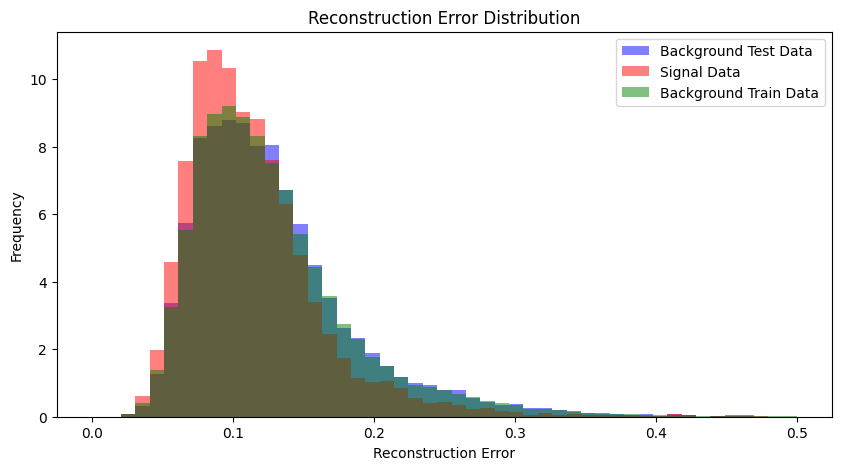

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 0.5, 50)
ax.hist(
    diff_bg_test,
    bins=bins,
    alpha=0.5,
    label="Background Test Data",
    color="blue",
    density=True,
)
ax.hist(diff_signal, bins=bins, alpha=0.5, label="Signal Data", color="red", density=True)
ax.hist(
    diff_bg_train,
    bins=bins,
    alpha=0.5,
    label="Background Train Data",
    color="green",
    density=True,
)

ax.set_xlabel("Reconstruction Error")
ax.set_ylabel("Frequency")
ax.set_title("Reconstruction Error Distribution")
ax.legend()
plt.show()